# INbreast paired CC/MLO pipeline
Notebook vodi kroz instalaciju, proveru podataka, sanity check, trening i evaluaciju.

In [1]:
!pip install -r requirements.txt



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Podesite putanju do raspakovanog INbreast skupa.

In [ ]:
DATA_ROOT = 'C:\\Users\\Neda\\Downloads\\INBREAST-AMS'
OUTPUT = 'C:\\Users\\Neda\\Downloads\\INBREAST-AMS\\artifacts'


In [7]:
!python train.py --data-root "{DATA_ROOT}" --output-dir "{OUTPUT}" --mode prepare
import pandas as pd
display(pd.read_csv(f'{OUTPUT}/dataset_summary.csv'))
display(pd.read_csv(f'{OUTPUT}/metadata_pairs.csv').tail())


Parovi: 187, pacijenti: 107, train: 158, val: 29


,item,value
0,dicom_found,410
1,labeled_images,377
2,complete_pairs,187
3,patients,107
4,positive_pairs,48
5,label_conflicts,0
6,annotated_views,313


,pair_id,patient_id,side,label,label_conflict,cc_image_id,cc_dicom_path,cc_xml_path,cc_has_roi,mlo_image_id,mlo_dicom_path,mlo_xml_path,mlo_has_roi,split
182,fd746d25eb40b3dc_R,fd746d25eb40b3dc,R,0,0,20587148,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,20587200,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,train
183,fdf4a1516f88b280_L,fdf4a1516f88b280,L,0,0,50996854,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,50996800,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,val
184,fdf4a1516f88b280_R,fdf4a1516f88b280,R,0,0,50996881,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,50996827,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,val
185,fe7d005dcbbfb46d_L,fe7d005dcbbfb46d,L,0,0,22580680,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,22580732,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,train
186,fe7d005dcbbfb46d_R,fe7d005dcbbfb46d,R,1,0,22580654,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,22580706,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,C:\Users\Neda\Downloads\INBREAST-AMS\INbreast ...,1,train


Parovi: 187, pacijenti: 107, train: 158, val: 29
Sanity check: C:\Users\Neda\Downloads\INBREAST-AMS\artifacts\sanity\paired_overlays.png


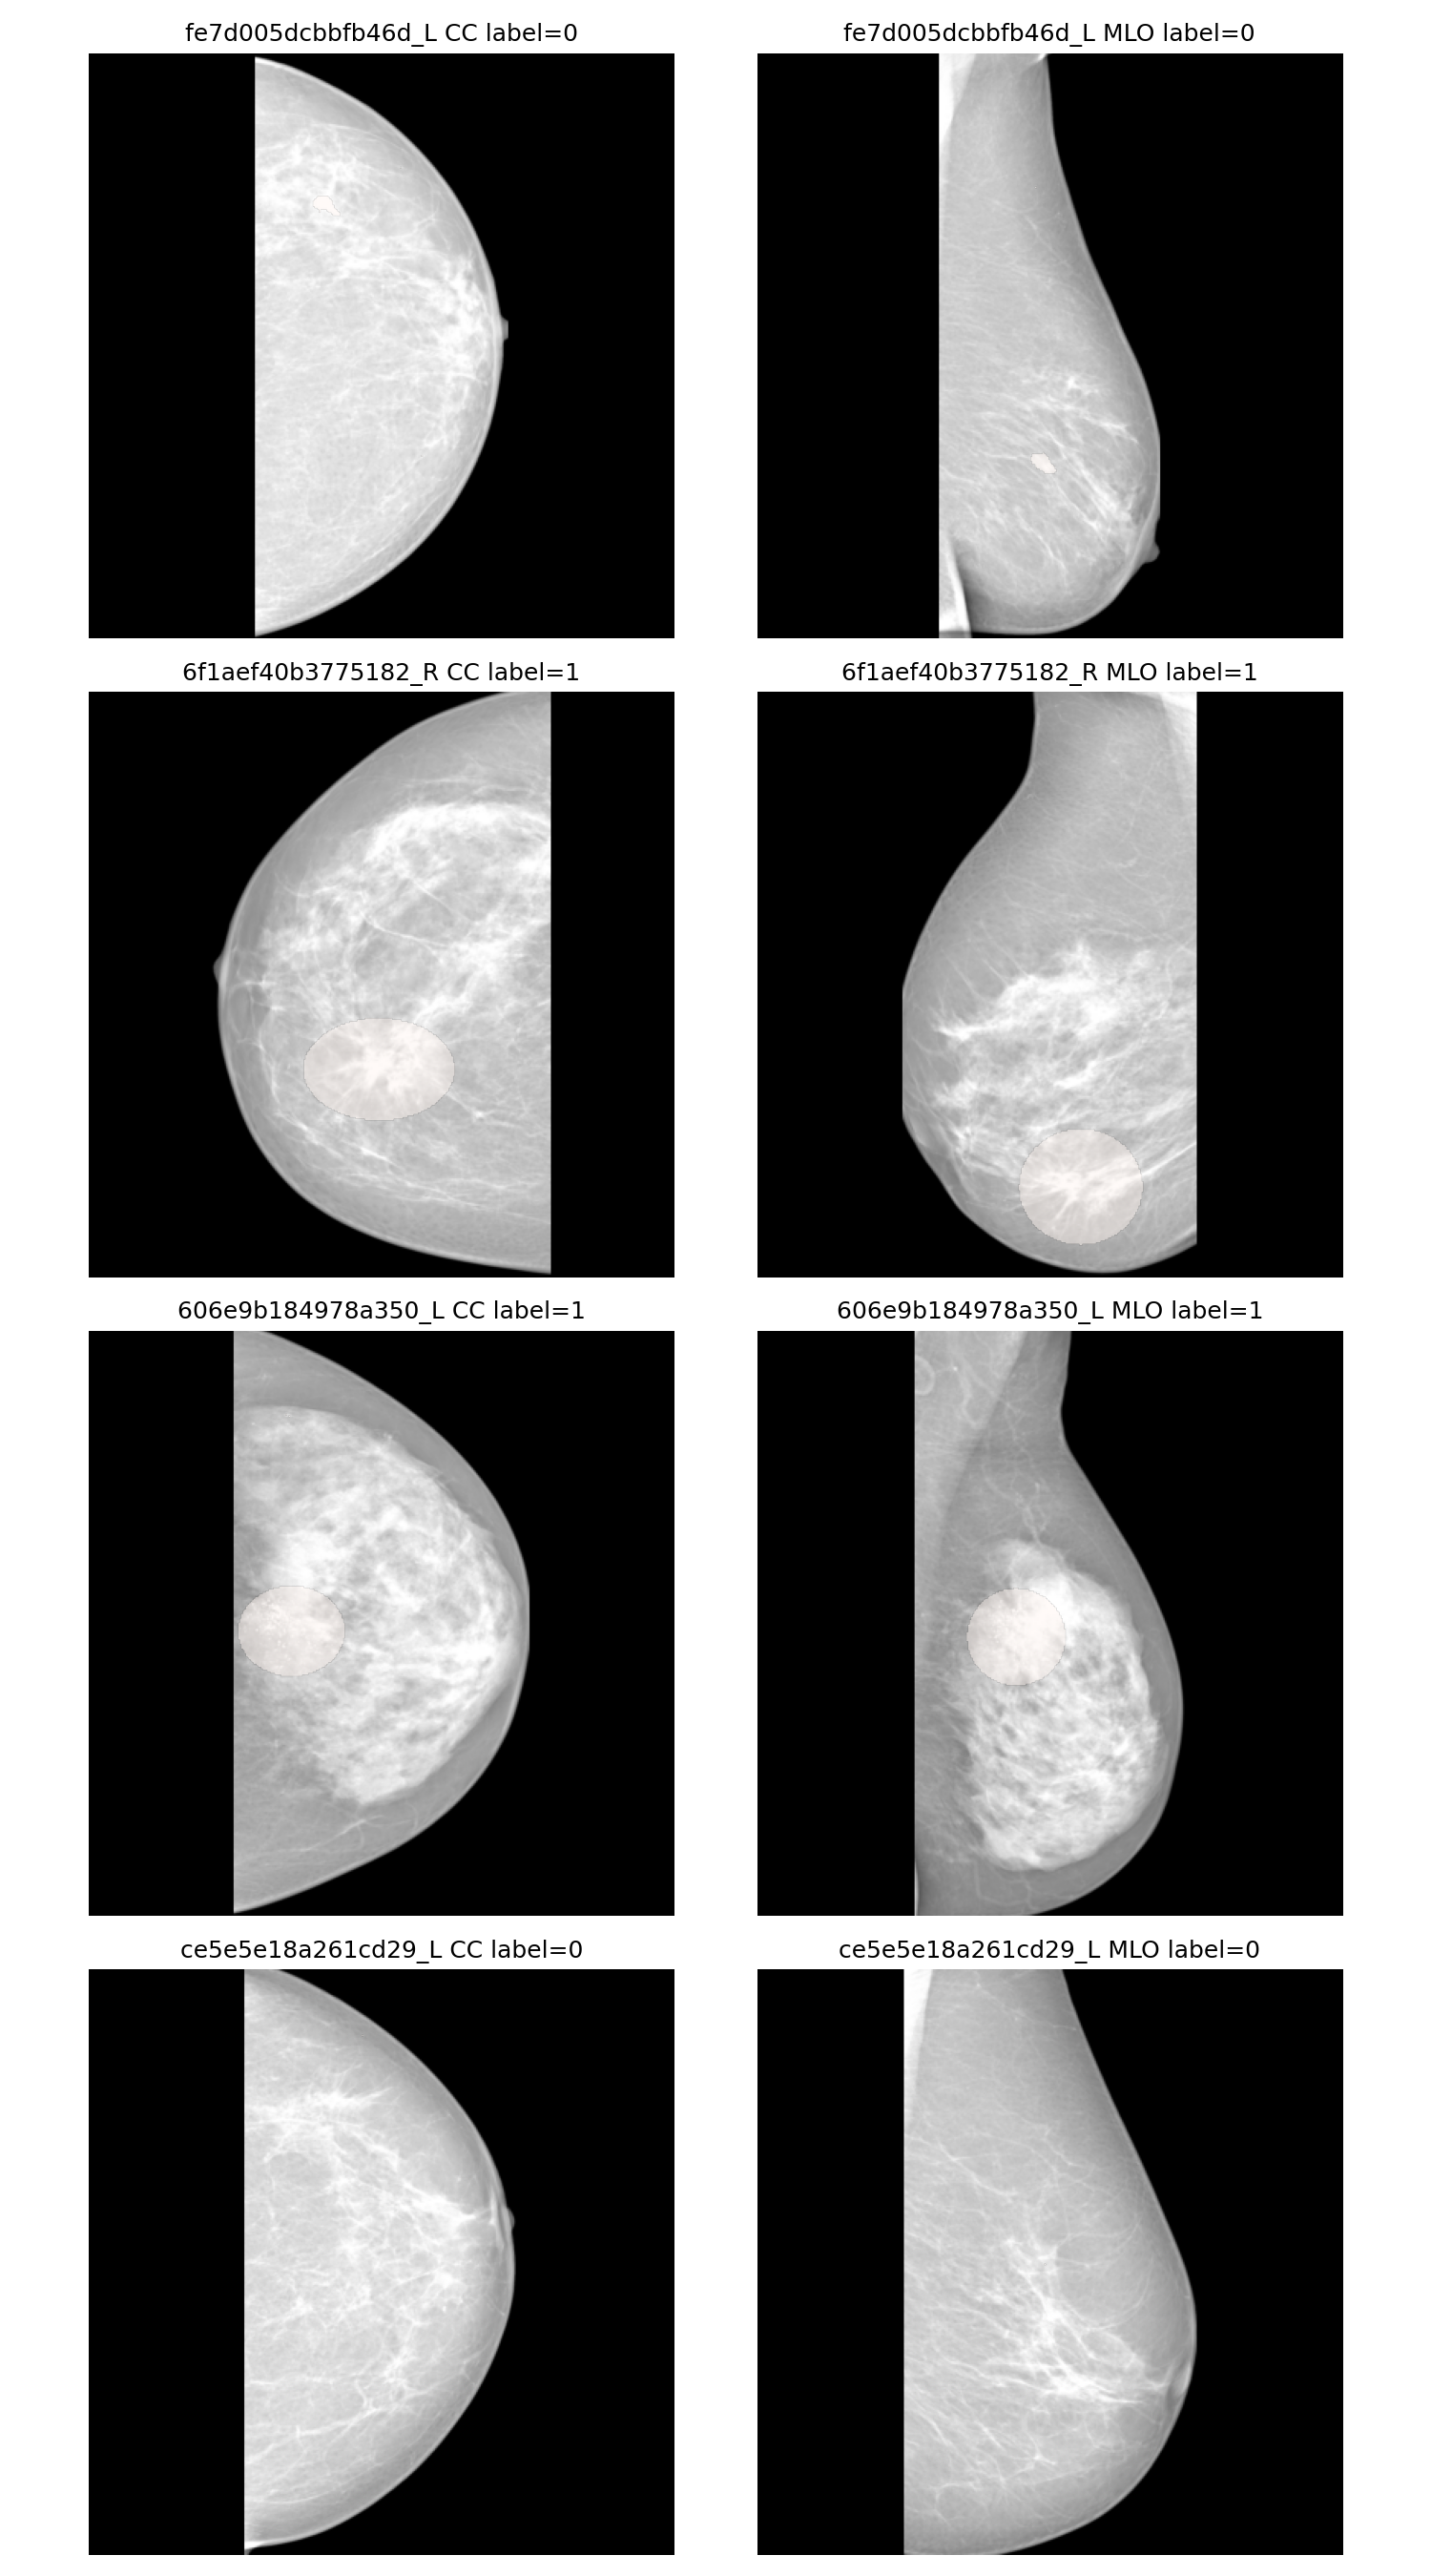

In [8]:
!python train.py --data-root "{DATA_ROOT}" --output-dir "{OUTPUT}" --mode sanity --workers 2
from IPython.display import Image, display
display(Image(filename=f'{OUTPUT}/sanity/paired_overlays.png'))


In [9]:
# Kratak smoke test; povećajte --epochs za završni trening.
!python train.py --data-root "{DATA_ROOT}" --output-dir "{OUTPUT}" --mode train --epochs 2 --batch-size 2 --workers 2


Parovi: 187, pacijenti: 107, train: 158, val: 29
Device: cuda
Epoch 001: train=1.1275 val=1.0443 F1@.5=0.0000
Epoch 002: train=1.2558 val=1.0853 F1@.5=0.0000


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [10]:
!python train.py --data-root "{DATA_ROOT}" --output-dir "{OUTPUT}" --mode evaluate --batch-size 2 --workers 2
import json
print(json.dumps(json.load(open(f'{OUTPUT}/metrics.json')), indent=2))


Parovi: 187, pacijenti: 107, train: 158, val: 29
Device: cuda
{
  "classification_at_05": {
    "threshold": 0.5,
    "f1": 0.0,
    "precision": 0.0,
    "sensitivity": 0.0,
    "specificity": 1.0,
    "balanced_accuracy": 0.5,
    "confusion_matrix": [
      [
        22,
        0
      ],
      [
        7,
        0
      ]
    ],
    "roc_auc": 0.6655844155844156,
    "pr_auc": 0.47317460317460314
  },
  "classification_tuned": {
    "threshold": 0.36000000000000004,
    "f1": 0.5882352941176471,
    "precision": 0.5,
    "sensitivity": 0.7142857142857143,
    "specificity": 0.7727272727272727,
    "balanced_accuracy": 0.7435064935064934,
    "confusion_matrix": [
      [
        17,
        5
      ],
      [
        2,
        5
      ]
    ],
    "roc_auc": 0.6655844155844156,
    "pr_auc": 0.47317460317460314
  },
  "localization_threshold": 0.20000000000000004,
  "localization": {
    "annotated_views": 46,
    "cc": {
      "count": 23,
      "dice_mean": 0.0342507909133357

c:\Users\Neda\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
